# Defining equations for lid cavity in 2D

## Continuity

$$

\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0 \\

$$

## Momentum balances in x and y directions

$$

\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{\partial p}{\partial x} + \nu \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right) \\

\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{\partial p}{\partial y} + \nu \left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)

$$

## Boundary conditions

- At the lid (top boundary): $u(x, 1) = U$, $v(x, 1) = 0$
- At the bottom and side walls: $u = 0$, $v = 0$
- At the walls: $\frac{\partial p}{\partial n} = 0$ (no normal pressure gradient)

# Aim
We now have equations to describe the flow, so we can apply a general PINN to approximate the solutions for say, $u$ and $v$.
To find a loss function, we can use the residuals of the governing equations and the boundary conditions. The loss function can be defined as:

$$

\mathcal{R}_{\Omega} = \left(u u_x + v u_y + p_x - \frac{1}{Re}(u_{xx} + u_{yy})\right)^2 +
\left( u v_x + v v_y + p_y - \frac{1}{Re}(v_{xx} + v_{yy}) \right)^2 + \left( u_x + v_y \right)^2

$$

At the top boundary (lid):

$$

\mathcal{R}_{BC}^{top} = (u - 1)^2 + v^2

$$

At the bottom and side walls:

$$

\mathcal{R}_{BC}^{walls} = u^2 + v^2

$$

Thus, the total loss function can be defined as:

$$

\mathcal{L}
=
\int_{\Omega}
\left(
R_u^2 + R_v^2 + R_c^2
\right)\, d\Omega
+
\lambda_{BC}
\int_{\partial\Omega}
R_{BC}\, ds

$$

# Implementing a general PINN for the lid cavity problem



In [22]:
import torch
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
# Reynolds number
Re = 100.0

In [25]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)  # outputs: psi, p
        )

    def forward(self, x):
        return self.net(x)


model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [27]:
def interior_points(n):
    x = torch.rand(n, 1)
    y = torch.rand(n, 1)
    return torch.cat([x, y], dim=1).to(device)


def boundary_points(n):
    x = torch.rand(n, 1)
    y0 = torch.zeros(n, 1)
    y1 = torch.ones(n, 1)
    x0 = torch.zeros(n, 1)
    x1 = torch.ones(n, 1)

    top = torch.cat([x, y1], dim=1)
    bottom = torch.cat([x, y0], dim=1)
    left = torch.cat([x0, x], dim=1)
    right = torch.cat([x1, x], dim=1)

    return top.to(device), bottom.to(device), left.to(device), right.to(device)

In [63]:

def residual(xy):
    xy.requires_grad_(True)
    output = model(xy)

    psi = output[:, 0:1]
    p   = output[:, 1:2]

    # ---- First derivative of psi ----
    grad_psi = torch.autograd.grad(
        psi, xy,
        grad_outputs=torch.ones_like(psi),
        create_graph=True
    )[0]

    psi_x = grad_psi[:, 0:1]
    psi_y = grad_psi[:, 1:2]

    u = psi_y
    v = -psi_x

    # ---- First derivatives of u, v, p ----
    grad_u = torch.autograd.grad(
        u, xy,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    grad_v = torch.autograd.grad(
        v, xy,
        grad_outputs=torch.ones_like(v),
        create_graph=True
    )[0]

    v_x = grad_v[:, 0:1]
    v_y = grad_v[:, 1:2]

    grad_p = torch.autograd.grad(
        p, xy,
        grad_outputs=torch.ones_like(p),
        create_graph=True
    )[0]

    p_x = grad_p[:, 0:1]
    p_y = grad_p[:, 1:2]

    # ---- Second derivatives ----
    u_xx = torch.autograd.grad(
        u_x, xy,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:, 0:1]

    u_yy = torch.autograd.grad(
        u_y, xy,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0][:, 1:2]

    v_xx = torch.autograd.grad(
        v_x, xy,
        grad_outputs=torch.ones_like(v_x),
        create_graph=True
    )[0][:, 0:1]

    v_yy = torch.autograd.grad(
        v_y, xy,
        grad_outputs=torch.ones_like(v_y),
        create_graph=True
    )[0][:, 1:2]

    # ---- Momentum residuals ----
    R_u = u*u_x + v*u_y + p_x - (1/Re)*(u_xx + u_yy)
    R_v = u*v_x + v*v_y + p_y - (1/Re)*(v_xx + v_yy)

    return R_u, R_v, u, v

In [71]:
n_int = 5000
n_bc = 1000

xy_int = interior_points(n_int)

top, bottom, left, right = boundary_points(n_bc)

def total_loss():
    R_u, R_v, _, _ = residual(xy_int)
    loss_int = torch.mean(R_u**2 + R_v**2)

    psi_top = model(top)[:, 0:1]
    _, _, u_top, v_top = residual(top)

    loss_top = torch.mean((u_top - 1)**2 + v_top**2 + psi_top**2)

    # Other walls
    psi_bottom = model(bottom)[:, 0:1]
    psi_left   = model(left)[:, 0:1]
    psi_right  = model(right)[:, 0:1]

    _, _, u_bottom, v_bottom = residual(bottom)
    _, _, u_left, v_left = residual(left)
    _, _, u_right, v_right = residual(right)

    loss_walls = (
        torch.mean(u_bottom**2 + v_bottom**2 + psi_bottom**2) +
        torch.mean(u_left**2 + v_left**2 + psi_left**2) +
        torch.mean(u_right**2 + v_right**2 + psi_right**2)
    )

    # Optional: Pressure pinning for stability
    xy_ref = torch.tensor([[0.0, 0.0]], dtype=torch.float32).to(next(model.parameters()).device)
    p_ref = model(xy_ref)[0, 1]
    loss_pressure = p_ref**2

    return 50*loss_int + 20*(loss_top + loss_walls) + loss_pressure

In [74]:
adam = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Starting Adam training...")

for epoch in range(1_000):
    
    adam.zero_grad()
    loss = total_loss()
    loss.backward()
    adam.step()
    
    if epoch % 250 == 0:
        print(f"Adam Iter {epoch} | Loss: {loss.item():.6e}")

print("Adam complete.\n")

Starting Adam training...
Adam Iter 0 | Loss: 9.231089e+00
Adam Iter 250 | Loss: 1.153471e+00
Adam Iter 500 | Loss: 1.076637e+00
Adam Iter 750 | Loss: 1.039023e+00
Adam complete.



In [75]:
lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    line_search_fn="strong_wolfe"
)

print("Starting LBFGS optimization...")

def closure():
    lbfgs.zero_grad()
    loss = total_loss()
    loss.backward()
    return loss

lbfgs.step(closure)

print("LBFGS complete.")

Starting LBFGS optimization...
LBFGS complete.


# Analysing the results with plots

Max U: 0.94252074
Min U: -0.16967922


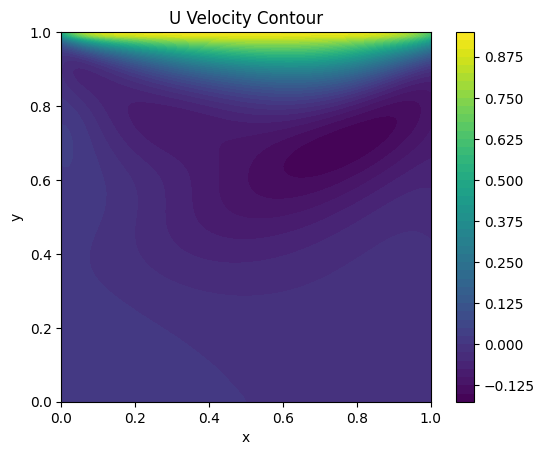

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure model is in evaluation mode
model.eval()

# Grid resolution
N = 100
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# Prepare input tensor
XY = torch.tensor(
    np.vstack([X.flatten(), Y.flatten()]).T,
    dtype=torch.float32
)

with torch.no_grad():
    pred = model(XY.to(next(model.parameters()).device)).cpu().numpy()

# Extract psi and pressure
psi = pred[:, 0].reshape(N, N)
p   = pred[:, 1].reshape(N, N)

# Grid spacing
dx = x[1] - x[0]
dy = y[1] - y[0]

# Compute velocity from streamfunction
u = np.gradient(psi, dy, axis=0)     # u = ψ_y
v = -np.gradient(psi, dx, axis=1)    # v = -ψ_x

velocity_magnitude = np.sqrt(u**2 + v**2)

print("Max U:", np.max(u))
print("Min U:", np.min(u))

# ==========================
# U Velocity Contour
# ==========================
plt.figure()
plt.contourf(X, Y, u, 50)
plt.colorbar()
plt.title("U Velocity Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.show()

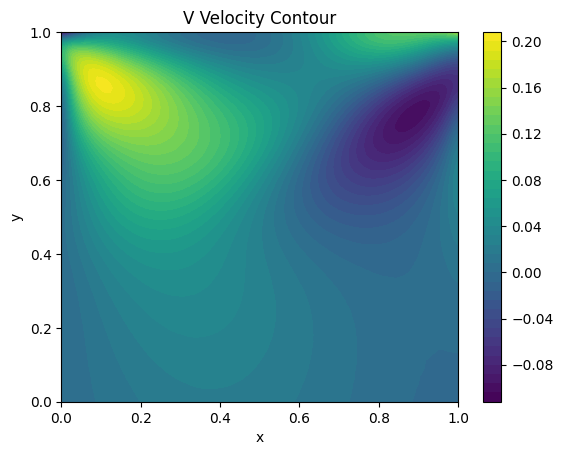

In [78]:
# ==========================
# 2. V-velocity contour
# ==========================
plt.figure()
plt.contourf(X, Y, v, 50)
plt.colorbar()
plt.title("V Velocity Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

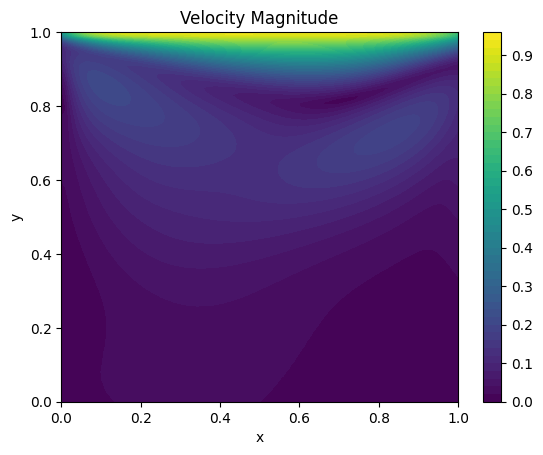

In [79]:
# ==========================
# 3. Velocity Magnitude
# ==========================
plt.figure()
plt.contourf(X, Y, velocity_magnitude, 50)
plt.colorbar()
plt.title("Velocity Magnitude")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

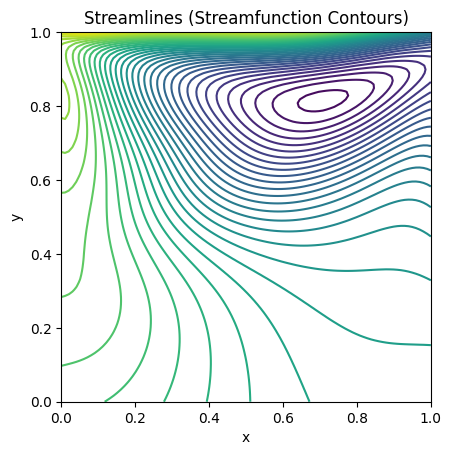

In [80]:
plt.figure()
plt.contour(X, Y, psi, 40)
plt.title("Streamlines (Streamfunction Contours)")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.show()